In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)



In [20]:
# Set Keras backend to torch as specified in model training
os.environ["KERAS_BACKEND"] = "torch"
from keras.models import load_model



In [21]:
#  Load the preprocessed data
data_path = "/Users/rupamhaldar/Desktop/CChunP/data/telco_preprocessed.xlsx"
print(f"Loading data from {data_path}...")
df = pd.read_excel(data_path)



Loading data from /Users/rupamhaldar/Desktop/CChunP/data/telco_preprocessed.xlsx...


In [22]:

X = df.drop(['Churn Label'], axis=1)
y = df['Churn Label']

# Train-Test Split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 42)

In [23]:

# 4. Load the trained Keras model
model_path = "/Users/rupamhaldar/Desktop/CChunP/telco_ann_model.keras"
print(f"Loading model from {model_path}...")
model = load_model(model_path)


Loading model from /Users/rupamhaldar/Desktop/CChunP/telco_ann_model.keras...


In [24]:
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 19)             │           475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │            77 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.26 KB)

 Trainable params: 789 (3.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,580 (6.18 KB)

In [28]:
#  Evaluate on the Test Set
print("\n--- Evaluating Model on Test Set ---")
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


--- Evaluating Model on Test Set ---
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - accuracy: 0.8240 - loss: 0.3993
Test Loss: 0.4111
Test Accuracy: 0.8168


In [30]:
y_pred_prob = model.predict(X_test)
y_pred_binary = (y_pred_prob > 0.5).astype(int)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 251us/step


In [ ]:

#  Print Classification Metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1260
           1       0.69      0.64      0.67       498

    accuracy                           0.82      1758
   macro avg       0.78      0.76      0.77      1758
weighted avg       0.81      0.82      0.81      1758



In [33]:
# Compute metrics
accuracy_val = accuracy_score(y_test, y_pred_binary)
precision_val = precision_score(y_test, y_pred_binary)
recall_val = recall_score(y_test, y_pred_binary)
f1_val = f1_score(y_test, y_pred_binary)
roc_auc_val = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy_val:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall:    {recall_val:.4f}")
print(f"F1-Score:  {f1_val:.4f}")
print(f"ROC AUC:   {roc_auc_val:.4f}")

Accuracy:  0.8168
Precision: 0.6897
Recall:    0.6426
F1-Score:  0.6653
ROC AUC:   0.8640


In [44]:
history_path = "/Users/rupamhaldar/Desktop/CChunP/model_history.json"

import json

with open(history_path, "r") as f:
    history = json.load(f)

print(history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


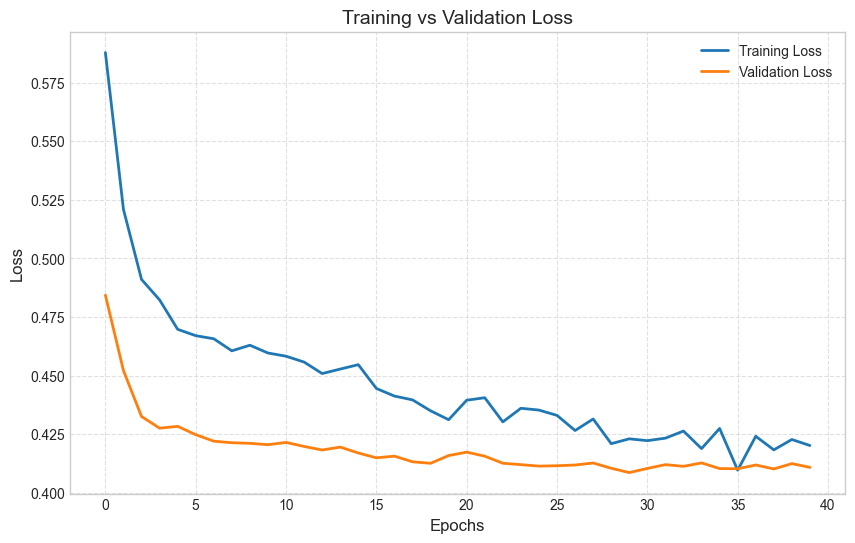

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

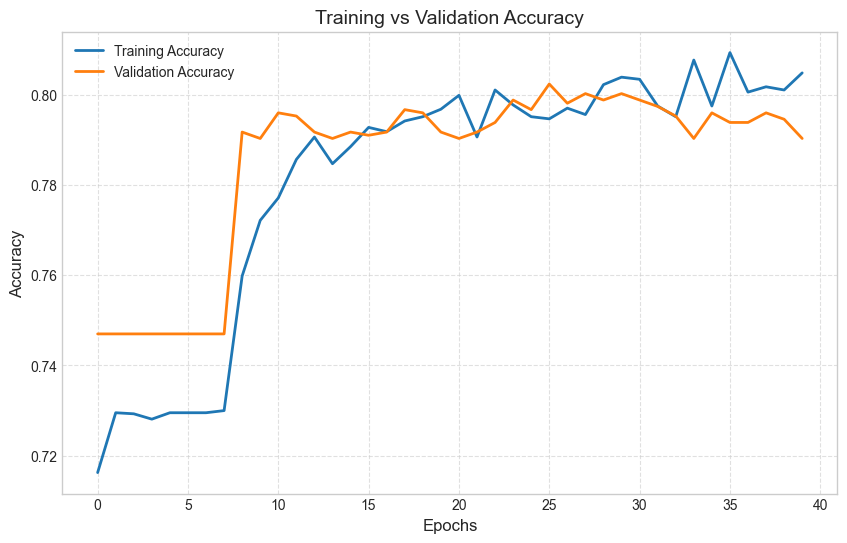

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(history['accuracy'],
         label='Training Accuracy',
         linewidth=2)

plt.plot(history['val_accuracy'],
         label='Validation Accuracy',
         linewidth=2)

plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

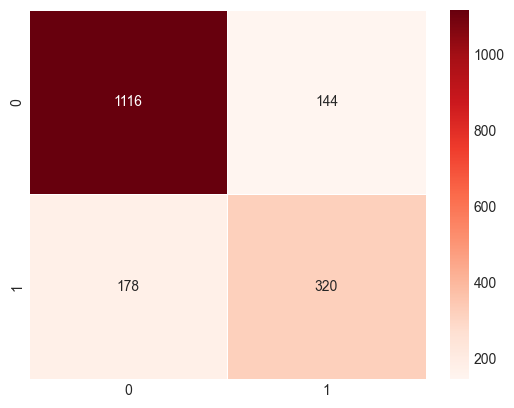

In [49]:
from sklearn.metrics import confusion_matrix , accuracy_score
cm = confusion_matrix(y_test , y_pred_binary )

sns.heatmap(cm  ,fmt="d", annot = True , cmap = "Reds" , linewidths = 0.7)
plt.show()

In [50]:
acc = accuracy_score(y_test , y_pred_binary)

acc

0.8168373151308305